# Notebook for Prediction Models

#### This Notebook explores finding from prection models. The goal is to work with the data to build and evaluate prediction models that capture the relationship between the descriptive features and the target feature. This dataset is used from database of California wildfire accident.

## **PART 1**

### Data Preparation and Understanding

In [22]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning - Preprocessing and Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score


In [23]:
# Load your dataset
df = pd.read_csv("cal-wildfires-24231301-modified.csv")

### Splitting dataset into two: 70% training and 30% test

In [24]:
#Split dataset
train_set, test_set = train_test_split(df, test_size=0.3, stratify=df["_Damage"], random_state=42)

# Save datasets to a new CSV file
train_set.to_csv("cal_wildfire_training_set.csv", index=False)

test_set.to_csv("cal_wildfire_test_set.csv", index=False)


In [25]:
# Define features and target
features = [
    "Assessed_Improved_Value_parcel",
    "Latitude",
    "Longitude",
    "Structure_Category",
    "_Roof_Construction",
    "_Vent_Screen",
    "_Eaves",
    "_Exterior_Siding",
    "_Window_Pane",
    "_DeckPorch_Elevated"
]
target = "_Damage"

# Select features from the training set
X_train = train_set[features]
y_train = train_set[target]

### Correlation between continous features

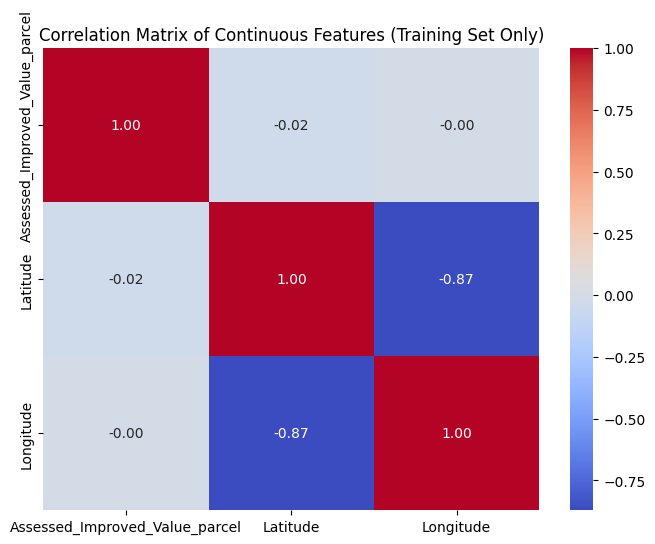

In [26]:
# plots for features
continuous_features = ["Assessed_Improved_Value_parcel", "Latitude", "Longitude"]

corr_matrix = X_train[continuous_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Continuous Features (Training Set Only)")
plt.show()

### Observation

The correlation matrix of continuous features indicates a strong negative linear relationship between Latitude and Longitude (r = -0.87), which reflects the underlying geographic orientation of the data and may introduce multicollinearity if both variables are used in regression models. In contrast, Assessed_Improved_Value_parcel demonstrates negligible correlation with both Latitude (r = -0.02) and Longitude (r ≈ 0), suggesting spatial independence of property value across the sampled area. Given the high correlation between spatial coordinates, dimensionality reduction techniques or feature selection may be considered to mitigate redundancy in linear models.

### Plots of continuous features vs target

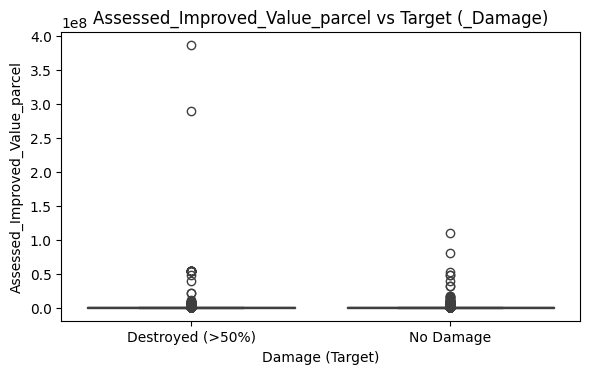

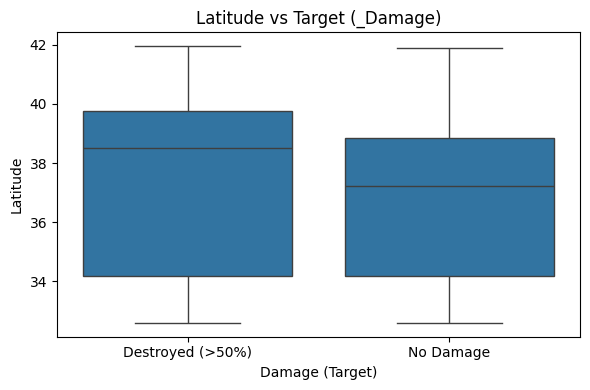

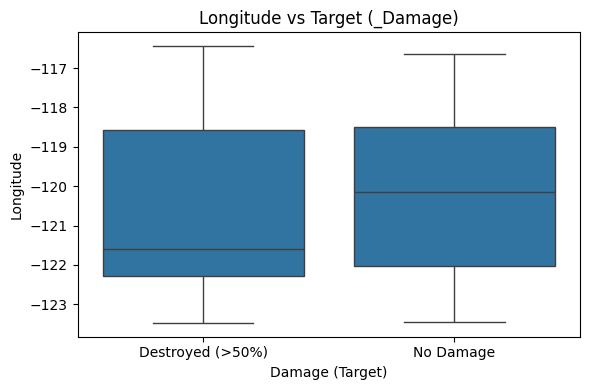

In [27]:
# plots for features
for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=y_train, y=X_train[feature])
    plt.title(f"{feature} vs Target (_Damage)")
    plt.xlabel("Damage (Target)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


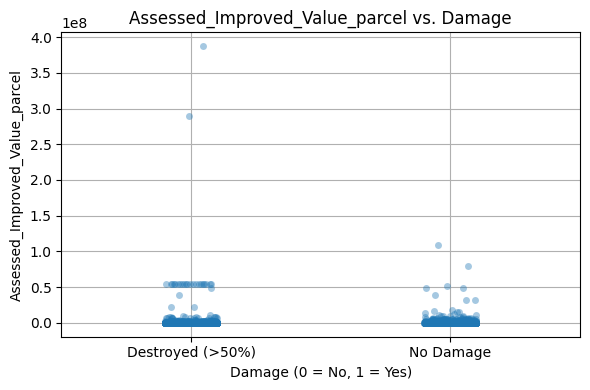

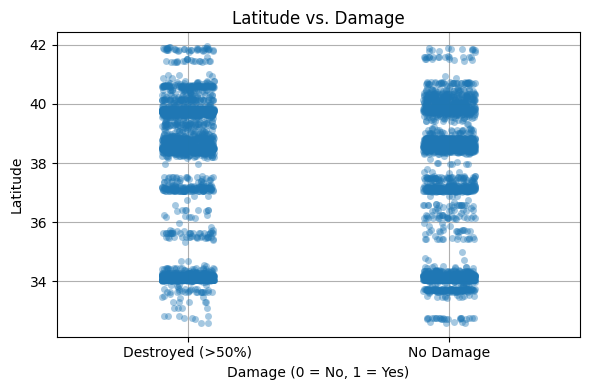

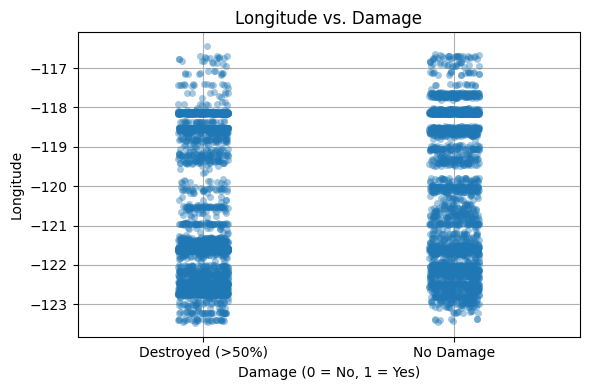

In [28]:
#plots for features
plot_df = X_train[continuous_features].copy()
plot_df["_Damage"] = y_train

for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.stripplot(x="_Damage", y=feature, data=plot_df, jitter=True, alpha=0.4)
    plt.title(f"{feature} vs. Damage")
    plt.xlabel("Damage (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Observations

From observations above, it is seen that there is a good correlation between longitude/latitude and damage. However, this will not be beneficial for training models and prediction. On the other hand assessed value could have protentional in prediction. 

### Plots of categorical features vs target

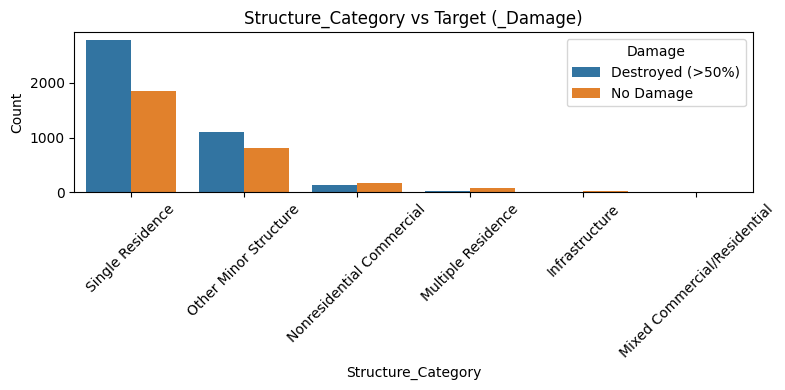

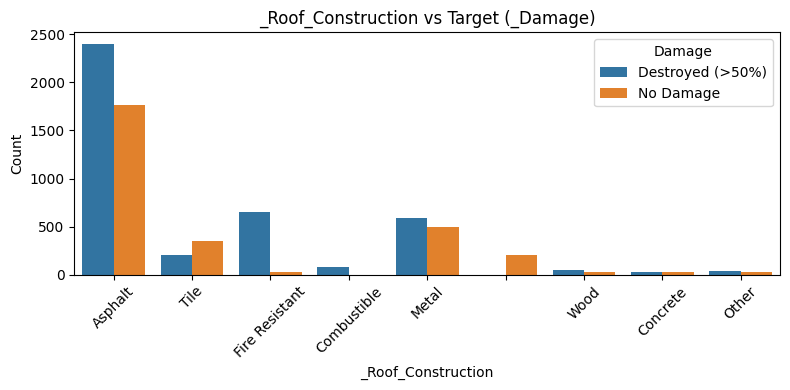

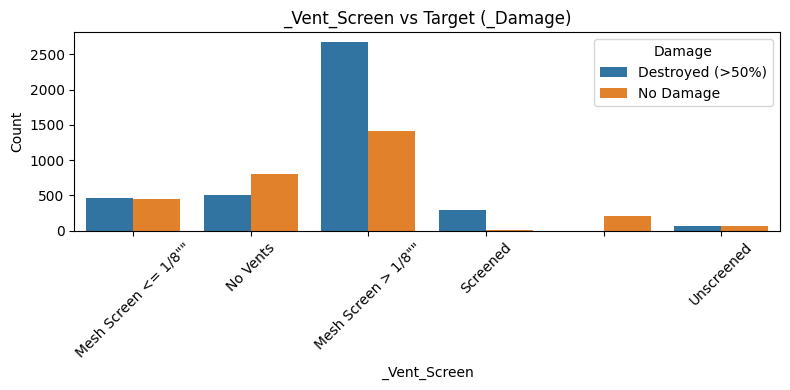

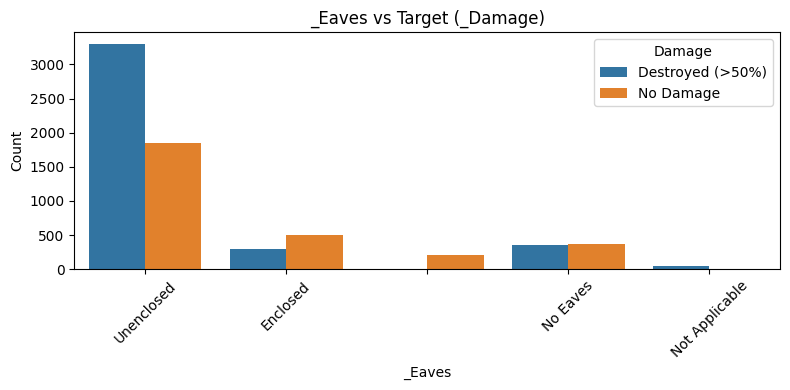

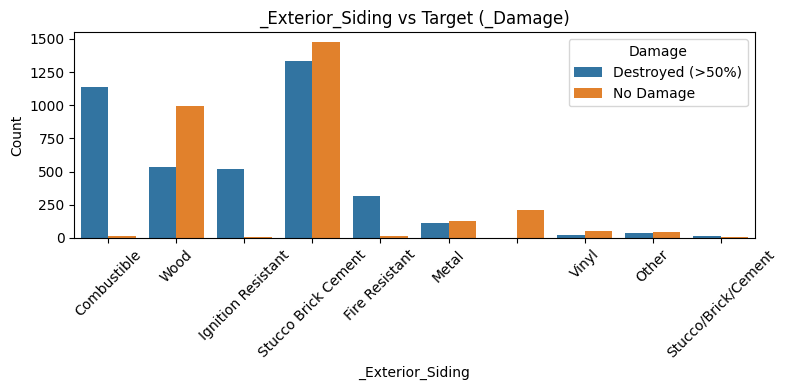

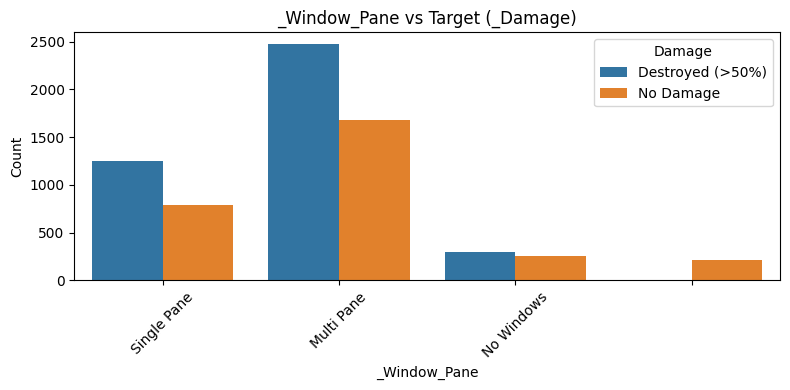

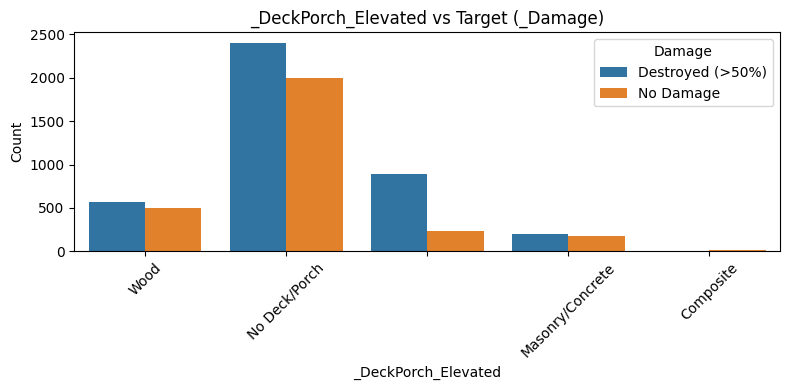

In [29]:
# plots for features
categorical_features = [
    "Structure_Category", "_Roof_Construction", "_Vent_Screen",
    "_Eaves", "_Exterior_Siding", "_Window_Pane", "_DeckPorch_Elevated"
]

for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=X_train[feature], hue=y_train)
    plt.title(f"{feature} vs Target (_Damage)")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Damage")
    plt.tight_layout()
    plt.show()

### Observations

In regards to categorical features, they are much more usable for training models. Roof construction, exterior siding, and window pane have many different features which can bring a good observation for future. The same with structure category, and deck/porch elevated as the data would be almost 100% complete. Vent screen, eaves does not have many features expanding this category, therefore, it would not be very beneficial for training the model.

## **PART 2**

### Linear regression

Linear regression tries to find the best-fitting line that predicts the target variable based on the input features. 
This part looks more closely on training the dataset to predict features through linear regression.

### Training Model

In [30]:
# Check values in _Damage
print(df["_Damage"].value_counts())

# Map and convert strings into int
mapping = {
    "No Damage": 0,
    "Destroyed (>50%)": 1
}
df["_Damage_num"] = df["_Damage"].map(mapping)

# Drop any rows where mapping didn’t find a match
df = df.dropna(subset=["_Damage_num"])

# Converting to integer
df["_Damage_num"] = df["_Damage_num"].astype(int)

# spliting on the numeric target
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    df,
    test_size=0.3,
    stratify=df["_Damage_num"],
    random_state=42
)

# Converting _Damage_num as target
features = [
    "Assessed_Improved_Value_parcel",
    "Latitude",
    "Longitude",
    "Structure_Category",
    "_Roof_Construction",
    "_Vent_Screen",
    "_Eaves",
    "_Exterior_Siding",
    "_Window_Pane",
    "_DeckPorch_Elevated"
]
X_train = train_set[features]
y_train = train_set["_Damage_num"]
X_test  = test_set[features]
y_test  = test_set["_Damage_num"]

# One‐hot encode + fit model safely:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,  drop_first=True).reindex(
    columns=X_train_encoded.columns, fill_value=0
)

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_encoded, y_train)

print()
print("✓ Trained on", X_train_encoded.shape[0], "examples with target distribution")
print()
print(y_train.value_counts(normalize=True))


_Damage
Destroyed (>50%)    5807
No Damage           4193
Name: count, dtype: int64

✓ Trained on 7000 examples with target distribution

_Damage_num
1    0.580714
0    0.419286
Name: proportion, dtype: float64


### Breakdown of the results:

Damage
- 5807 instances of "Destroyed"
- 4193 instances of "No Damage"

The model is being trained on 7000 examples after splitting.

Damage_num = shows the proportional distribution of the target variable.
- Destroyed (1) = 0.580714 (58%) of data corresponds to
- No Damage (0) = 0.419286 (42%) of data corresponds to

### Coefficients

In [31]:
# Get feature names from the data frame
feature_names = X_train_encoded.columns

# Get the coefficients from the trained model
coefficients = lin_reg.coef_

# Create a data frame to display coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print("Linear Regression Coefficients:")
print(coef_df)


Linear Regression Coefficients:
                                            Feature   Coefficient
15                          _Roof_Construction_Wood  1.043942e+00
13                         _Roof_Construction_Other  1.030853e+00
12                         _Roof_Construction_Metal  9.429006e-01
8                        _Roof_Construction_Asphalt  8.717899e-01
10                      _Roof_Construction_Concrete  8.126024e-01
14                          _Roof_Construction_Tile  7.513776e-01
11                _Roof_Construction_Fire Resistant  5.439880e-01
9                    _Roof_Construction_Combustible  5.387651e-01
27              _Exterior_Siding_Ignition Resistant  3.025585e-01
25                     _Exterior_Siding_Combustible  2.357952e-01
6          Structure_Category_Other Minor Structure  1.985435e-01
24                                _Eaves_Unenclosed  1.971465e-01
23                            _Eaves_Not Applicable  1.865400e-01
7               Structure_Category_Single Re

### Observations
The coefficients represent the weights of each feature.
- positive coefficients = as the feature value increases, the predicted target value increases.
- negative coefficients = as the feature value increases, the predicted target value decreases.
- larger c. = have a stronger influence on the predicted target.
- small c. = suggest that those features have little influence on predicting the target value.

In this observation, for example, roof contruction wood (1.0439) indicate that properties are more likely to be damaged. The same is for example, deck/porch elevated composite (-0.4366) indicate that properties are less likely to have significant damage as well.

Some features related to structure types appear important in predicting damage, as their coefficinets are strong. For example, exterior siding, roof construction, or deck/porch elevated. On the other hand, latitude and longitude have coefficients close to zero, therefore the influence is weak and less relevant in predicting damage.

### Predicted Target value

In [32]:
# Predict on training set
y_pred_train = lin_reg.predict(X_train_encoded)

# Show first 10 predicted values
print("\nFirst 10 predicted values (probability-like):")
print(np.round(y_pred_train[:10], 3))

# Apply threshold of 0.5
y_pred_train_class = (y_pred_train >= 0.5).astype(int)

print("\nFirst 10 predicted class labels:")
print(y_pred_train_class[:10])

# Evaluation
print("\nTraining Set Evaluation:")
print("Accuracy:", accuracy_score(y_train, y_pred_train_class))
print("F1 Score:", f1_score(y_train, y_pred_train_class))
print("Precision:", precision_score(y_train, y_pred_train_class))
print("Recall:", recall_score(y_train, y_pred_train_class))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_class))



First 10 predicted values (probability-like):
[0.198 0.524 0.97  1.03  0.589 0.864 0.511 0.144 0.343 0.882]

First 10 predicted class labels:
[0 1 1 1 1 1 1 0 0 1]

Training Set Evaluation:
Accuracy: 0.7824285714285715
F1 Score: 0.8007326965851106
Precision: 0.8552263834544438
Recall: 0.7527675276752768

Confusion Matrix:
 [[2417  518]
 [1005 3060]]


### Observations

The first table, there are the raw outputs for the first 10 training examples. Linear regression is not constrained to only [0, 1], the values can be slighly above or below 1.

In the second result table, the treshold is applied. Therefore anything more than 0.5 becomes class 1, and below is class 0.

Training set accuracy
- there are 78% of all training samples correctly classified.
- there are 85% actually damaged samples.
- the model caught 75% of all truly damaged structures.
- F1 score balances at about 80% - mean of precision and recall combined.
     - precision means few false positives
     - recall means it misses actual destroyed cases

Confusion Matrix
[TN, FP] , [FN, TP]
- true negatives 2417 = correctlu predicted no damage
- false positives 518 = predicted destroyed but actually no damage
- false negatives 1005 = predicted no damage but actually destroyed
- true positives 3060 = correctlu predicted destroyed


### Cross-Validation

In [33]:
# Custom scorers that threshold predictions
def thresholded_accuracy(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    return accuracy_score(y_true, y_pred_class)

def thresholded_precision(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    return precision_score(y_true, y_pred_class)

def thresholded_recall(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    return recall_score(y_true, y_pred_class)

def thresholded_f1(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    return f1_score(y_true, y_pred_class)

# Create scorers
scorers = {
    "accuracy": make_scorer(thresholded_accuracy),
    "precision": make_scorer(thresholded_precision),
    "recall": make_scorer(thresholded_recall),
    "f1": make_scorer(thresholded_f1)
}

# Full dataset prep
X_full = pd.get_dummies(df[features], drop_first=True)
y_full = df[target].map({"No Damage": 0, "Destroyed (>50%)": 1})

# Cross-validation
cv_results = cross_validate(LinearRegression(), X_full, y_full, cv=5, scoring=scorers)

# Results
print("\nCross-Validation Results (averaged across 5 folds):")
print("Accuracy:", np.mean(cv_results["test_accuracy"]))
print("Precision:", np.mean(cv_results["test_precision"]))
print("Recall:", np.mean(cv_results["test_recall"]))
print("F1 Score:", np.mean(cv_results["test_f1"]))



Cross-Validation Results (averaged across 5 folds):
Accuracy: 0.7714
Precision: 0.84158007909431
Recall: 0.7470718364462963
F1 Score: 0.7913790564528778



### Observations

A technique to assess the performance of model by training and testing it on different subsets of data. In this case, it is 5 fold cross validation. Therefore the data is split into 5 parts, the model is trained on 4 parts and tested on the remaining 1 part. This process repeats 5 times. At the end, the results are averaged, giving better reliable metrics, which can be compared using a single train-test split.

- accuracy 77% = proportion of correct predictions over the total no of predictions. On average the model is 77% correct.
- precision 84% = predicted positive instances that were actually correct. When the model predicts destroyed, it is correct 85% of the time.
- recall 75% = actual positives that were correctly identified. The model catches 75% of all destroyed structures.
- F1 score 79% = mean of precision and recall. Overall 79% is a really good result.

Overall the model is performing well. There is a good balance between correcly identifying damage and avoiding false positives. 

## **PART 3**

### Logistic Regression

Logistic regression uses algorithm that predicts the probability of a binary outcome based on input features. It works the best when there is a linear relationship between the input variables and the target.



### Train Model

In [34]:
# Train model
log_reg = LogisticRegression(max_iter=1000)     # max number of iterations during training
log_reg.fit(X_train_encoded, y_train)


LogisticRegression(max_iter=1000)

### Coefficients

In [35]:
# Get coefficients
log_coefficients = log_reg.coef_[0]
feature_names = X_train_encoded.columns

# Create a data frame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_coefficients
}).sort_values(by="Coefficient", ascending=False)

print("Logistic Regression Coefficients:")
print(coef_df)


Logistic Regression Coefficients:
                                            Feature   Coefficient
25                     _Exterior_Siding_Combustible  1.128681e+00
17                 _Vent_Screen_Mesh Screen > 1/8""  8.245235e-01
24                                _Eaves_Unenclosed  7.679068e-01
11                _Roof_Construction_Fire Resistant  6.808484e-01
27              _Exterior_Siding_Ignition Resistant  5.096991e-01
26                  _Exterior_Siding_Fire Resistant  3.285089e-01
19                            _Vent_Screen_Screened  3.103751e-01
36                         _Window_Pane_Single Pane  1.927748e-01
34                          _Window_Pane_Multi Pane  1.382116e-01
7               Structure_Category_Single Residence  1.377150e-01
1                                          Latitude  1.072808e-01
6          Structure_Category_Other Minor Structure  9.167243e-02
9                    _Roof_Construction_Combustible  8.157585e-02
23                            _Eaves_Not A

### Observations

Each coefficient reflects the influence of a feature on the log-odds of the positive class. The larger the absolute value, the stronger influence.
- positive coefficients = increase the probability of damage.
- negative coefficients = decrease the probability of damage.

Positive coefficients
- exterior siding combustible (1.13) = increases the risk of damage, the materials make the structure more vulnerable.
- roof construction fire resistant (0.68) = suprising enough, but the roof still suggest to be risky.
- eaves unenclosed (0.77) = unenclosed eaves are a fire risk, rising flames getting and and raising damage chances.
- window pane single pane (0.19) = suggesting, that single pane windows are more likely to break during heat, which increases risk.

Negative coefficients
- exterior siding wood (-1.01) = decreases the chance of damage, it could be because the material is stronger.
- no vents (-0.62) = no vents reduce entry points for fire, less likely to be destroyed.
- eaves enclosed (-0.39) = enclosed are safer, again leading to less damage.

### Predicted Target Value

In [36]:
# Predict probabilities and classes for training set
y_train_pred_prob = log_reg.predict_proba(X_train_encoded)[:, 1]
y_train_pred = log_reg.predict(X_train_encoded)

print("First 10 predicted probabilities:")
print(np.round(y_train_pred_prob[:10], 3))

print("\nFirst 10 predicted class labels:")
print(y_train_pred[:10])

# Evaluation
print("\nTraining Set Evaluation:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1 Score:", f1_score(y_train, y_train_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_train_pred))


First 10 predicted probabilities:
[0.21  0.477 0.938 0.949 0.308 0.707 0.647 0.194 0.347 0.366]

First 10 predicted class labels:
[0 0 1 1 0 1 1 0 0 0]

Training Set Evaluation:
Accuracy: 0.6992857142857143
Precision: 0.7086882453151618
Recall: 0.8186961869618696
F1 Score: 0.75973062435795

Confusion Matrix:
 [[1567 1368]
 [ 737 3328]]


### Observations

First 10 predicted probabilities = the model's confidence levels for predicting the positive class.
- values closer to 1 = more confident the property was destroyed.
- values closer to 0 = more confident the property had no damage.

Second table = the actual class predictions with threshold.
- numbers were rounded up >= 0.5 - labeled as 1 (Destroyed)
- everything < 0.5 was rounded to 0 (No damage)

Training set metrics
- accuracy 70% = of predictions were correct overall
- precision 70% = of all the properties predicted to be destroyed
- recall 81% = of all truly destroyed properties were correctlu predicted.
- F1 score 76% = mean of precision and recall

This shows a decent model, that leans more toward sensitivity.

Confusion matrix
- true negatives (1567) = correctly predicted no damage
- false positives (1368) = incorrectly predicted destroyed when it was not
- false negatives (737) = missed predictions, predicted no damage - real damage
- true positives (3328) = correctly predicted destroyed

This model leans toward predicting destruction, which results a lot of false positives. That could pull down precision and accuracy.

### Cross-Validation

In [37]:

# Encode data
X_full = df[features]
y_full = df["_Damage_num"]
X_full_encoded = pd.get_dummies(X_full, drop_first=True)

# Align - differences
X_full_encoded = X_full_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Cross-validation
cv_results = cross_validate(
    LogisticRegression(max_iter=1000),
    X_full_encoded,
    y_full,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1"]
)

# Results
print("Cross-Validation Results (averaged across 5 folds):")
print("Accuracy:", np.mean(cv_results["test_accuracy"]))
print("Precision:", np.mean(cv_results["test_precision"]))
print("Recall:", np.mean(cv_results["test_recall"]))
print("F1 Score:", np.mean(cv_results["test_f1"]))


Cross-Validation Results (averaged across 5 folds):
Accuracy: 0.7141
Precision: 0.7421047889198608
Recall: 0.7878412135066661
F1 Score: 0.7633905063846871


### Observations

These results are average values across 5 folds of data. It is for better estimation of model's performance by testing and training on multiple dataset. The cross-validation results give a better estimate of how the model will perform. Since there is multiple times training, it reduces the risk.

- accuracy 71% = the model correctly predicted the target class acrossthe 5 folds.
- precision 74% = of all instances that were predicted as destroyed, 74% were actually destroyed. This means that the model has a relatively high ability to avoid false positives.
- recall 78% = of all instances that were actually destroyed, 78% were correctly predicted. The model is good at identifying the properties destroyed.
- F1 score 76% = the model performs well in both predicting destruction and minimizing errors.

This model is doing good overall, it has flows in predicting less damaged properties.

## **PART 4**

### Random Forest

Random forest method builds many decision trees and combines their results to make a more accurate and stable predicitons. Each tree is trained on a random subset of data, which improved generalization.

### Train Model

In [38]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# have the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_encoded, y_train)

y_train_pred = rf_model.predict(X_train_encoded)
y_test_pred = rf_model.predict(X_test_encoded)


### Predicted target value

In [39]:

train_probs = rf_model.predict_proba(X_train_encoded)[:, 1]
train_preds = rf_model.predict(X_train_encoded)

print("\nFirst 10 predicted probabilities:")
print(train_probs[:10])

print("\nFirst 10 predicted classes:")
print(train_preds[:10])

# Predictions on the test set
test_probs = rf_model.predict_proba(X_test_encoded)[:, 1]
test_preds = rf_model.predict(X_test_encoded)

print("\nFirst 10 predicted probabilities (test set):")
print(test_probs[:10])

print("\nFirst 10 predicted classes (test set):")
print(test_preds[:10])

print(f"\nShape of train predictions: {train_preds.shape}")
print(f"Shape of test predictions: {test_preds.shape}")



First 10 predicted probabilities:
[0.08 0.77 1.   1.   0.15 1.   0.01 0.05 0.24 0.99]

First 10 predicted classes:
[0 1 1 1 0 1 0 0 0 1]

First 10 predicted probabilities (test set):
[0.   0.24 0.   0.01 1.   0.56 1.   0.99 0.64 0.  ]

First 10 predicted classes (test set):
[0 0 0 0 1 1 1 1 1 0]

Shape of train predictions: (7000,)
Shape of test predictions: (3000,)


### Observations

The first set is predicted probabilities for training set.
- a probability of 1.0 shows a very high confidence that the sample belongs to class 1.
- a probability of 0.0 shows high confidence that the sample belongs to class 0.

The second shows the labels 1.0 and 0.0 - there is a threshold of 0.5 used.

The third set is predicting probabilities for test set.
The forth set is predicting probabilities for test set with threshold.

There are 7000 samples in the training set and 3000 on test set.

In [40]:

# Predictions on the training set
train_probs = rf_model.predict_proba(X_train_encoded)[:, 1]
train_preds = rf_model.predict(X_train_encoded)

print("\nFirst 10 predicted probabilities:")
print(np.round(train_probs[:10], 3))

print("\nFirst 10 predicted class labels:")
print(train_preds[:10])

# Evaluation metrics
train_accuracy = accuracy_score(y_train, train_preds)
train_precision = precision_score(y_train, train_preds)
train_recall = recall_score(y_train, train_preds)
train_f1 = f1_score(y_train, train_preds)
train_conf_matrix = confusion_matrix(y_train, train_preds)

print("\nTraining Set Evaluation:")
print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"F1 Score: {train_f1}")
print("Confusion Matrix:\n", train_conf_matrix)



First 10 predicted probabilities:
[0.08 0.77 1.   1.   0.15 1.   0.01 0.05 0.24 0.99]

First 10 predicted class labels:
[0 1 1 1 0 1 0 0 0 1]

Training Set Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[2935    0]
 [   0 4065]]


### Observations

The first set predicts how likely each sample is to belong to class 1.
- 0.08 means that the model is 8% confident that the sample is class 1
- 1.0 means the model is fully confident that the sample is class 1

The second set predicted class labels based on the probabilities, using threshold of 0.5.

The model performance on the training set is evaluated using common classification metrics:
- accuracy 1.0 = the model made 100% correct predictions on the training set.
- precision 1.0 = every time the model predicted a 1, is was correct.
- recall 1.0 = the model corrrectly identified all the actual positive samples, with no false negatives.
- F1 score 1.0 = the model achieved the best possible balance between precision and recall.

Confusion Matrix:
The first row represents the actual 0 class - negative class:
- 2935 is the number of correctlu predicted 0 samples - true negatives
- 0 is the number of incorrectly predicted 1 samples - false positives
The second row represents the actual 1 class - postive class:
- 0 is the number of incorrectly predicted 0 samples - false negatives
- 4065 is the number of correctlu predicted 1 samples - true positives

Overall, the model is likely overfitting the training data, because it seems to have memorized the data rather than learning generalizable patterns.

## **PART 5**

### Findings and Conclussion

In this notebook, it was proven, that random forest model worked the best to predict future data. It was trained the best to further predict the values. This has been done, due to the model dividing values into smaller groups. This helped the model to train on better accurate data. The notebook started with linear regression, followed logistic regression and finished with random forest. As more models were predicted, it can be seen, the models performed better each time. Therefore, more complex models performed better. As the tasks were divided into smaller parts, the models were trained better and accuracy was higher. The tasks were done as binary classificatoin, and the random forest model captured the relationships between the features and targets better than logistic regression. 

These models could be improved by better selection of values or improved values. Some columns could be joined together(groups, ratios...), so there could be more accurate data. More available data, could enhance the precision of models. Another improvement could be combination of different models. Logistic regression and Random forest are both very strong models, therefore combining them together could improve the model predictions.

Overall, all of these models did very good and provided further findings for future predictions.